In [15]:
import os
import pandas as pd

ruta_base = "/home/jeff/Trabajo/Cedulas/Rotacion"  # Cambia esto por la ruta a tu carpeta raíz
data = []  # Lista para guardar (ruta, etiqueta)

for carpeta_actual, subcarpetas, archivos in os.walk(ruta_base):
    for archivo in archivos:
        if archivo.lower().endswith((".jpg", ".png")):
            ruta_completa = os.path.join(carpeta_actual, archivo)
            label = os.path.basename(carpeta_actual)
            data.append({"Path": ruta_completa, "Label": label,"Angle":0.0})

# Crear el DataFrame
df = pd.DataFrame(data)
df['Label_decode'], uniques = pd.factorize(df["Label"])
stratiffy=[i for i in uniques]
print(df.head())
#df.to_excel("df_oritation.xlsx")


                                                Path      Label  Angle  \
0  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo    0.0   
1  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo    0.0   
2  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo    0.0   
3  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo    0.0   
4  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo    0.0   

   Label_decode  
0             0  
1             0  
2             0  
3             0  
4             0  


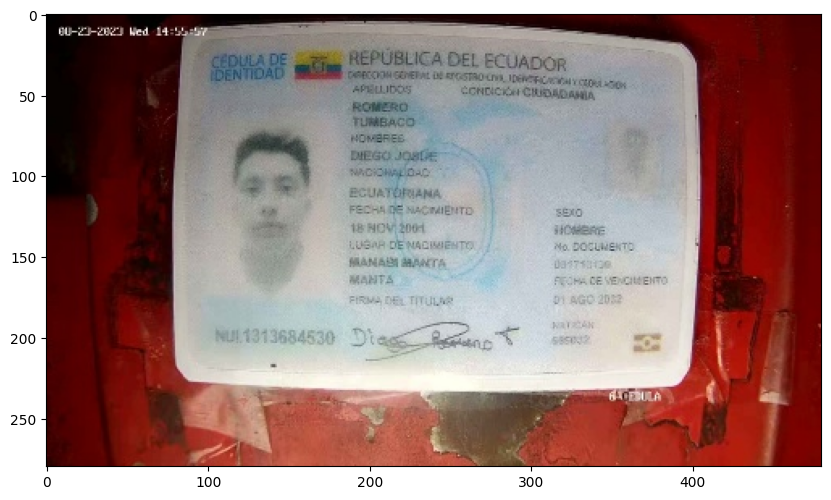

Ángulo estimado: 51.43°


In [16]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
def detectar_angulo(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Binarización adaptativa
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY_INV, 15, 10)
    
    # Contornos
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    angles = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 100:
            continue
        rect = cv2.minAreaRect(cnt)
        angle = rect[-1]
        if angle < -45:
            angle = 90 + angle
        angles.append(angle)
    
    if angles:
        return np.mean(angles)
    return 0

# Cargar imagen
img = cv2.imread(df["Path"][0])
img_show=Image.fromarray(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.show()
angulo = detectar_angulo(img)
print(f"Ángulo estimado: {angulo:.2f}°")


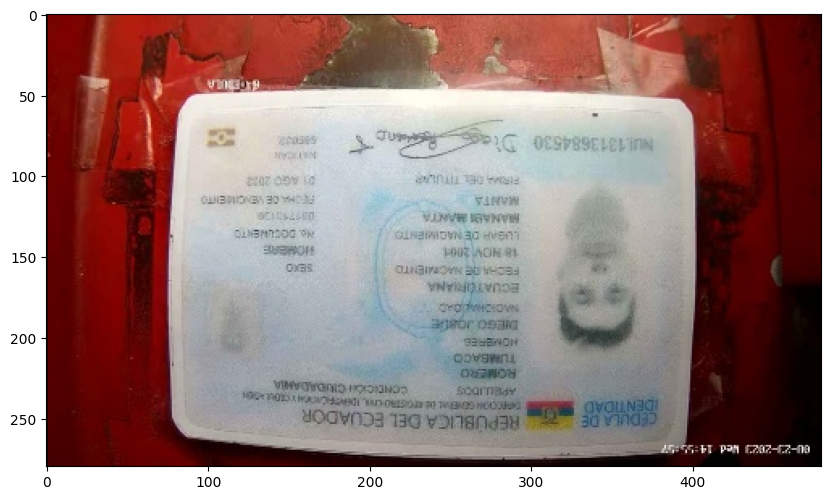

In [17]:
import cv2

escala=1
# Obtener dimensiones
(h, w) = img.shape[:2]
centro = (w // 2, h // 2)

# Crear la matriz de rotación: ángulo en grados y escala
M = cv2.getRotationMatrix2D(centro, -180, escala)

# Aplicar la rotación
imagen_rotada = cv2.warpAffine(img, M, (w, h))

img_show=Image.fromarray(cv2.cvtColor(imagen_rotada,cv2.COLOR_BGR2RGB))
plt.figure(figsize=(10,10))
plt.imshow(img_show)
plt.show()


In [18]:
import random
random.seed(42)

df_rot=df.sample(n=20,random_state=42)
df_rot["Angle"]=df_rot["Angle"].apply(lambda x:-random.uniform(1,360))
print(df_rot.head())

                                                  Path      Label       Angle  \
73   /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo -230.554221   
218  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo   -9.978861   
25   /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo  -99.735525   
208  /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo  -81.132655   
9    /home/jeff/Trabajo/Cedulas/Rotacion/No_angulo/...  No_angulo -265.393166   

     Label_decode  
73              0  
218             0  
25              0  
208             0  
9               0  


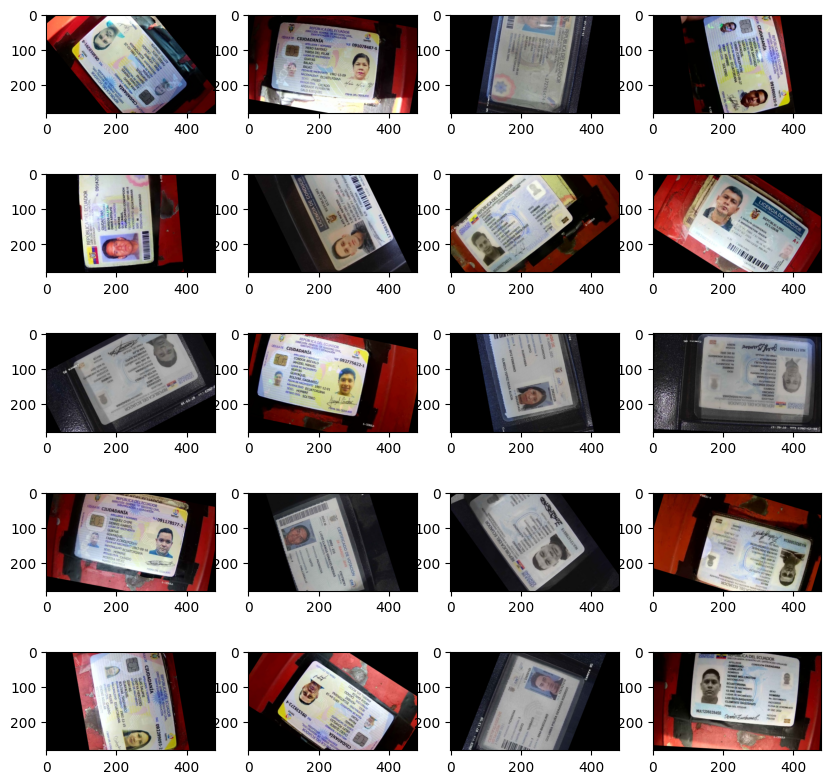

In [19]:
fig , axes = plt.subplots(ncols=4,nrows=5,figsize=(10,10))
axes=axes.flatten()
i=0
for index, d_f in df_rot.iterrows():
    img = cv2.imread(d_f["Path"])
    (h, w) = img.shape[:2]
    centro = (w // 2, h // 2)

    # Crear la matriz de rotación: ángulo en grados y escala
    M = cv2.getRotationMatrix2D(centro, d_f["Angle"], escala)

    # Aplicar la rotación
    imagen_rotada = cv2.warpAffine(img, M, (w, h))
    img_show=Image.fromarray(cv2.cvtColor(imagen_rotada,cv2.COLOR_BGR2RGB))
    axes[i].imshow(img_show)
    i+=1


In [20]:
porc=int(len(df)*0.7)
df_rot=df.sample(n=porc,random_state=42)
df_rot["Angle"]=df_rot["Angle"].apply(lambda x:-random.uniform(1,360))
df=df.drop(columns=["Label","Label_decode"])
df.update(df_rot)




In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning as L

class AngleRegressionModel(L.LightningModule):
    def __init__(self, input_shape, hidden_units, lambda_reg=0.0001, regularization=None):
        super().__init__()
        self.save_hyperparameters()

        self.hidden_units = hidden_units
        self.lambda_reg = lambda_reg
        self.regularization = regularization

        # Red neuronal
        layers = [nn.Flatten()]
        for units in hidden_units:
            layers.append(nn.Linear(input_shape, units))
            layers.append(nn.LeakyReLU(0.01))
            input_shape = units

        layers.append(nn.Linear(input_shape, 2))  # salida: [sin(θ), cos(θ)]
        self.regressor = nn.Sequential(*layers)

        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.regressor(x)

    def configure_optimizers(self):
        return torch.optim.Adam(
            self.parameters(),
            lr=1e-4,
            weight_decay=self.lambda_reg if self.regularization == "L2" else 0.0
        )

    def compute_regularization_loss(self):
        reg_loss = 0.0
        if self.regularization == "L1":
            for param in self.parameters():
                reg_loss += torch.sum(torch.abs(param))
        elif self.regularization == "L2":
            for param in self.parameters():
                reg_loss += torch.sum(param ** 2)
        return self.lambda_reg * reg_loss

    def training_step(self, batch, batch_idx):
        x, target = batch
        pred = self(x)
        loss = self.loss_fn(pred, target)
        if self.regularization in ["L1", "L2"]:
            loss += self.compute_regularization_loss()
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, target = batch
        pred = self(x)
        loss = self.loss_fn(pred, target)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, target = batch
        pred = self(x)
        loss = self.loss_fn(pred, target)
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x = batch
        pred = self(x)
        return self.vector_to_angle(pred)

    @staticmethod
    def vector_to_angle(sin_cos):
        sin, cos = sin_cos[:, 0], sin_cos[:, 1]
        angles = torch.atan2(sin, cos)
        return torch.rad2deg(angles) % 360


In [53]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class AngleDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["Path"]).convert("RGB").rotate(row["Angle"])
        print(row["Angle"])
        angle = torch.tensor(row["Angle"], dtype=torch.float32)
        return self.transform(image), angle


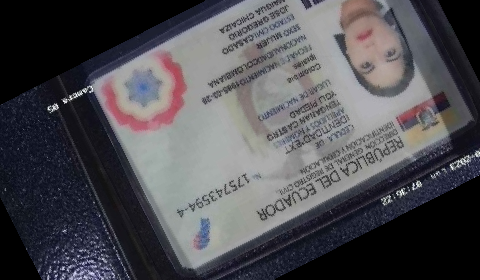

-153.06472566415155


TypeError: Unexpected type <class 'NoneType'>